# Food Rescue CV: Data Pipeline Setup
Food-101 loading, preprocessing, and stratified data-fraction splits (10%/50%/100%) for ResNet18 vs ViT-B/16 comparison.

## 1. Mount Google Drive
This keeps data, checkpoints, and logs persistent across Colab session resets.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/food-rescue-cv'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
print('Project dir ready at', PROJECT_DIR)

Mounted at /content/drive
Project dir ready at /content/drive/MyDrive/food-rescue-cv


In [7]:
from pathlib import Path

CHECKPOINT_DIR = Path(PROJECT_DIR) / "checkpoints"
RESULTS_DIR = Path(PROJECT_DIR) / "results"

## 2. Install packages

In [10]:
!pip install -q timm wandb

import torch
import torchvision
from torchvision.models import vit_b_16
%pip install -Uq "mlop[full]"
import mlop
import random
import numpy as np

LEARNING_RATE = 1e-4
EPOCHS = 10
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 101
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())

Device: cuda
torch 2.11.0+cu128 | cuda available: True


## 3. Load Food-101
Downloads once to Drive-backed storage. `torchvision.datasets.Food101` handles train/test splits automatically.

In [11]:
from torchvision.datasets import Food101

DATA_ROOT = '/content/food101_data'  # local disk, faster download, not persisted

train_set = Food101(root=DATA_ROOT, split='train', download=True)
test_set = Food101(root=DATA_ROOT, split='test', download=True)

print('Train size:', len(train_set))
print('Test size:', len(test_set))
print('Num classes:', len(train_set.classes))
print('Sample classes:', train_set.classes[:5])

100%|██████████| 5.00G/5.00G [03:36<00:00, 23.1MB/s]


Train size: 75750
Test size: 25250
Num classes: 101
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


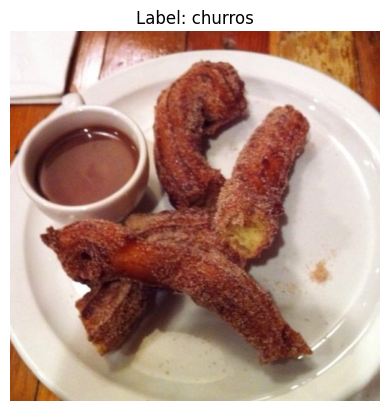

In [12]:
# Spot check: view a sample image and its label
import matplotlib.pyplot as plt

img, label = train_set[0]
plt.imshow(img)
plt.title(f'Label: {train_set.classes[label]}')
plt.axis('off')
plt.show()

## 4. Preprocessing
Shared transforms for ResNet18 and ViT-B/16 (both pretrained on ImageNet). Keeping preprocessing identical across models so performance differences come from architecture, not input handling.

In [13]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Reload datasets with transforms applied
train_set = Food101(root=DATA_ROOT, split='train', transform=train_transform, download=False)
val_dataset = Food101(DATA_ROOT, split="train", transform=eval_transform, download=False)
test_set = Food101(root=DATA_ROOT, split='test', transform=eval_transform, download=False)

## 5. Stratified data-fraction splits (10% / 50% / 100%)
Each class proportionally represented at every fraction, reproducible via fixed seed.

In [14]:
BATCH_SIZE = 32
NUM_CLASSES = 101
NUM_WORKERS = 0

In [17]:
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

def stratified_subset(
    labels,
    fraction,
    candidate_indices=None,
    seed=SEED,
):
    if candidate_indices is None:
        candidate_indices = range(len(labels))

    rng = np.random.default_rng(seed)
    by_class = defaultdict(list)

    for index in candidate_indices:
        by_class[int(labels[index])].append(index)

    selected = []

    for class_indices in by_class.values():
        class_indices = np.asarray(class_indices)
        rng.shuffle(class_indices)

        n_keep = max(1, round(len(class_indices) * fraction))
        selected.extend(class_indices[:n_keep].tolist())

    return selected

food101_labels = np.asarray(train_set._labels)
val_indices = stratified_subset(food101_labels, fraction=0.10)
val_index_set = set(val_indices)
train_pool_indices = [
    index for index in range(len(food101_labels))
    if index not in val_index_set
]

FRACTIONS = [0.10, 0.50, 1.00]

fraction_indices = {
    fraction: stratified_subset(
        food101_labels,
        fraction=fraction,
        candidate_indices=train_pool_indices,
    )
    for fraction in FRACTIONS
}

val_subset = Subset(val_dataset, val_indices)
test_subset = test_set

print("Validation size:", len(val_subset))
for fraction, indices in fraction_indices.items():
    print(f"{fraction:.0%} training size:", len(indices))


Validation size: 7575
10% training size: 6868
50% training size: 34138
100% training size: 68175


## 6. DataLoaders
Quick sanity check that batches load correctly before wiring up training.

In [18]:

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}

def make_train_loader(data_fraction):
    train_subset = Subset(
        train_set,
        fraction_indices[data_fraction],
    )

    train_loader = DataLoader(
        train_subset,
        shuffle=True,
        **loader_kwargs,
    )
    return train_loader

val_loader = DataLoader(
    val_subset,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
      test_subset,
      shuffle=False,
      **loader_kwargs,
)


## 7. Model

In [19]:
from torchvision.models import (
    ViT_B_16_Weights,
    vit_b_16,
)
import torch.nn as nn

def create_model(model_name, num_classes=NUM_CLASSES, pretrained=True):
    if model_name == "vit_b_16":
        weights = ViT_B_16_Weights.DEFAULT if pretrained else None
        model = vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)
    return model

## 8. Training

In [20]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    epoch,
    run=None,
    global_step=0,
    log_every=100,
):
    model.train()

    total_loss = 0.0
    top1_correct = 0
    total_examples = 0

    progress = tqdm(loader, desc=f"Train epoch {epoch}", leave=True)

    for batch_index, (images, labels) in enumerate(progress, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        top1_correct += logits.argmax(dim=1).eq(labels).sum().item()
        total_examples += batch_size
        global_step += 1

        running_loss = total_loss / total_examples
        running_top1 = top1_correct / total_examples

        progress.set_postfix(
            loss=f"{running_loss:.4f}",
            top1=f"{running_top1:.4f}",
        )

        if run is not None and (
            batch_index % log_every == 0 or batch_index == len(loader)
        ):
            run.log({
                "step": global_step,
                "epoch": epoch,
                "train/batch_loss": float(loss.item()),
                "train/running_loss": float(running_loss),
                "train/running_top1": float(running_top1),
            })

    return {
        "loss": total_loss / total_examples,
        "top1": top1_correct / total_examples,
        "global_step": global_step,
    }


In [21]:
def topk_correct(logits, labels, k):
    predictions = logits.topk(k, dim=1).indices
    return predictions.eq(labels.unsqueeze(1)).any(dim=1).sum().item()

@torch.no_grad()
def evaluate(model, loader, criterion, description="Validation"):
    model.eval()

    total_loss = 0.0
    top1_correct = 0
    top5_correct = 0
    total_examples = 0

    progress = tqdm(loader, desc=description, leave=False)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        top1_correct += topk_correct(logits, labels, k=1)
        top5_correct += topk_correct(logits, labels, k=5)
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "top1": top1_correct / total_examples,
        "top5": top5_correct / total_examples,
    }


In [22]:
def checkpoint_paths(run_name):
    return {
        "last": CHECKPOINT_DIR / f"{run_name}_last.pt",
        "best": CHECKPOINT_DIR / f"{run_name}_best.pt",
    }


def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    best_val_top1,
    epochs_without_improvement,
    config,
    global_step,
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_top1": best_val_top1,
        "epochs_without_improvement": epochs_without_improvement,
        "config": config,
        "global_step": global_step,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer):
    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_top1 = checkpoint["best_val_top1"]
    global_step = checkpoint.get("global_step", 0)
    epochs_without_improvement = checkpoint.get(
        "epochs_without_improvement", 0
    )
    return (
        start_epoch,
        best_val_top1,
        epochs_without_improvement,
        global_step,
    )

In [23]:
mlop.login()

mlop: 🚀 15:22:42 | Authentication: initializing authentication

 - Please copy the API key provided in the web portal and paste it below

 - You can alternatively manually open https://app.mlop.ai/api-keys

 - You may exit at any time by pressing CTRL+C / ⌃+C



Enter API key: ··········


mlop: 🚀 15:22:57 | Authentication: logged in as dl-project


## 9. Experiments

In [24]:
import gc
import json

def run_experiment(config):
    random.seed(config["seed"])
    np.random.seed(config["seed"])
    torch.manual_seed(config["seed"])
    torch.cuda.manual_seed_all(config["seed"])

    run_name = (
        f'{config["model_name"]}'
        f'_frac{int(config["data_fraction"] * 100)}'
        f'_lr{config["learning_rate"]}'
        f'_wd{config["weight_decay"]}'
    )

    paths = checkpoint_paths(run_name)

    train_loader = make_train_loader(
        data_fraction=config["data_fraction"],
    )

    model = create_model(
        model_name=config["model_name"],
        pretrained=config["pretrained"],
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=config.get("label_smoothing", 0.0)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    start_epoch = 1
    best_val_top1 = -1.0
    epochs_without_improvement = 0
    global_step = 0
    early_stopping_patience = config.get("early_stopping_patience", 2)
    early_stopping_min_delta = config.get(
        "early_stopping_min_delta", 0.001
    )

    if config.get("resume", False) and paths["last"].exists():
        (
            start_epoch,
            best_val_top1,
            epochs_without_improvement,
            global_step,
        ) = load_checkpoint(paths["last"], model, optimizer)
        print(f"Resumed from epoch {start_epoch}")

    run = mlop.init(
        project="food-rescue-cv",
        name=run_name,
        config=config,
    )

    history = []

    try:
        for epoch in range(start_epoch, config["epochs"] + 1):
            train_metrics = train_one_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                epoch=epoch,
                run=run,
                global_step=global_step,
                log_every=config.get("log_every", 100),
            )
            global_step = train_metrics.pop("global_step")

            val_metrics = evaluate(
                model,
                val_loader,
                criterion,
                description=f"Validation epoch {epoch}",
            )

            epoch_record = {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_top1": train_metrics["top1"],
                "val_loss": val_metrics["loss"],
                "val_top1": val_metrics["top1"],
                "val_top5": val_metrics["top5"],
            }
            history.append(epoch_record)

            run.log({
                "step": global_step,
                "epoch": epoch,
                "train/loss": float(train_metrics["loss"]),
                "train/top1": float(train_metrics["top1"]),
                "val/loss": float(val_metrics["loss"]),
                "val/top1": float(val_metrics["top1"]),
                "val/top5": float(val_metrics["top5"]),
            })

            improved = (
                val_metrics["top1"]
                > best_val_top1 + early_stopping_min_delta
            )

            if improved:
                best_val_top1 = val_metrics["top1"]
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            save_checkpoint(
                paths["last"],
                model,
                optimizer,
                epoch,
                best_val_top1,
                epochs_without_improvement,
                config,
                global_step,
            )

            if improved:
              save_checkpoint(
                  paths["best"],
                  model,
                  optimizer,
                  epoch,
                  best_val_top1,
                  epochs_without_improvement,
                  config,
                  global_step,
              )

            with open(RESULTS_DIR / f"{run_name}_history.json", "w") as file:
                json.dump(history, file, indent=2)

            print(
                f'Epoch {epoch:02d}/{config["epochs"]} | '
                f'train loss {train_metrics["loss"]:.4f} | '
                f'train top-1 {train_metrics["top1"]:.4f} | '
                f'val loss {val_metrics["loss"]:.4f} | '
                f'val top-1 {val_metrics["top1"]:.4f} | '
                f'val top-5 {val_metrics["top5"]:.4f}'
            )
            print("Saved:", paths["last"])
            if improved:
                print("New best checkpoint:", paths["best"])
            should_stop = (
                early_stopping_patience is not None
                and epochs_without_improvement >= early_stopping_patience
            )
            if should_stop:
                print(
                    "Early stopping: validation top-1 did not improve by "
                    f"at least {early_stopping_min_delta:.4f} for "
                    f"{epochs_without_improvement} consecutive epochs."
                )
                break

    finally:
        print("Training loop ended.")

        if config.get("finish_mlop", False):
            run.finish()
            print("MLOP run finished.")
        else:
            print("Skipped run.finish().")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    return {
        "run_name": run_name,
        "best_val_top1": best_val_top1,
        "best_checkpoint": str(paths["best"]),
        "history": history,
    }


In [25]:
def evaluate_checkpoint(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
    config = checkpoint["config"]

    model = create_model(
        config["model_name"],
        pretrained=False,
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])

    criterion = nn.CrossEntropyLoss()
    metrics = evaluate(
        model,
        test_loader,
        criterion,
        description="Final test",
    )

    del model
    torch.cuda.empty_cache()
    return metrics

In [51]:
# sample run

sample_config = {
    "model_name": "vit_b_16",
    "pretrained": True,
    "data_fraction": 0.10,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.0,
    "batch_size": BATCH_SIZE,
    "epochs": 1,
    "seed": SEED,
    "log_every": 25,
    "resume": False,
    "finish_mlop": True,
}

print(run_experiment(sample_config))


mlop: 🚀 08:36:43 | Authentication: logged in as dl-project
mlop: 🚀 08:36:45 | Interface: find live updates at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/lApiG


Train epoch 1:   0%|          | 0/215 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 01/1 | train loss 3.1026 | train top-1 0.3196 | val loss 2.0745 | val top-1 0.5380 | val top-5 0.7956
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.0001_wd0.0001_last.pt
New best checkpoint: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.0001_wd0.0001_best.pt
Training loop ended.


mlop: 🚀 08:43:29 | Interface: find 106 synced entries at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/lApiG


MLOP run finished.
{'run_name': 'vit_b_16_frac10_lr0.0001_wd0.0001', 'best_val_top1': 0.5379537953795379, 'best_checkpoint': '/content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.0001_wd0.0001_best.pt', 'history': [{'epoch': 1, 'train_loss': 3.1025924838137753, 'train_top1': 0.3195981362842167, 'val_loss': 2.0745414074025925, 'val_top1': 0.5379537953795379, 'val_top5': 0.7956435643564357}]}


In [55]:
sample_test_metrics = evaluate_checkpoint(
    "/content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.0001_wd0.0001_best.pt"
)
print(sample_test_metrics)

Final test:   0%|          | 0/790 [00:00<?, ?it/s]

{'loss': 1.905801093592502, 'top1': 0.5786138613861386, 'top5': 0.8376633663366336}


In [56]:
# run ViT baseline

baseline_config = {
    "model_name": "vit_b_16",
    "pretrained": True,
    "data_fraction": 1.00,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.0,
    "batch_size": BATCH_SIZE,
    "epochs": 10,
    "seed": SEED,
    "log_every": 100,
    "resume": False,
    "finish_mlop": True,
    "run_label": "baseline_vit_test",
}

baseline_result = run_experiment(baseline_config)
baseline_test_metrics = evaluate_checkpoint(
    baseline_result["best_checkpoint"]
)
print("Baseline validation top-1:", baseline_result["best_val_top1"])
print("Baseline test metrics:", baseline_test_metrics)


mlop: 🚀 08:50:29 | Authentication: logged in as dl-project
mlop: 🚀 08:50:30 | Interface: find live updates at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/yFjr3


Train epoch 1:   0%|          | 0/2131 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 01/10 | train loss 1.5339 | train top-1 0.6225 | val loss 1.1330 | val top-1 0.7094 | val top-5 0.8961
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr0.0001_wd0.0001_last.pt
New best checkpoint: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr0.0001_wd0.0001_best.pt


Train epoch 2:   0%|          | 0/2131 [00:00<?, ?it/s]

...

Epoch 10/10 | train loss 0.1332 | train top-1 0.9583 | val loss 1.2713 | val top-1 0.7294 | val top-5 0.9011
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr0.0001_wd0.0001_last.pt
Training loop ended.


mlop: 🚀 16:59:22 | Interface: find 7211 synced entries at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/yFjr3


MLOP run finished.


Final test:   0%|          | 0/790 [00:00<?, ?it/s]

Baseline validation top-1: 0.7398019801980198
Baseline test metrics: {'loss': 0.7878861303915924, 'top1': 0.7868118811881188, 'top5': 0.949029702970297}


In [67]:
learning_rates = [5e-5, 1e-4, 5e-4, 1e-2]
weight_decays = [1e-4, 1e-2]

tuning_configs = [
    {
        "model_name": "vit_b_16",
        "pretrained": True,
        "data_fraction": 0.10,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "label_smoothing": 0.0,
        "batch_size": 32,
        "epochs": 3,
        "early_stopping_patience": 2,
        "early_stopping_min_delta": 0.001,
        "seed": SEED,
        "log_every": 50,
        "resume": False,
        "finish_mlop": True,
    }
    for learning_rate in learning_rates
    for weight_decay in weight_decays
]

tuning_results = []
for config in tuning_configs:
    tuning_results.append(run_experiment(config))


mlop: 🚀 19:17:34 | Authentication: logged in as dl-project
mlop: 🚀 19:17:37 | Interface: find live updates at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/bllZn


Train epoch 1:   0%|          | 0/215 [00:00<?, ?it/s]

Validation epoch 1:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 01/3 | train loss 3.2884 | train top-1 0.3136 | val loss 2.2266 | val top-1 0.5451 | val top-5 0.8098
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr5e-05_wd0.0001_last.pt
New best checkpoint: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr5e-05_wd0.0001_best.pt


Train epoch 2:   0%|          | 0/215 [00:00<?, ?it/s]

...

Epoch 02/3 | train loss 4.6617 | train top-1 0.0067 | val loss 4.6440 | val top-1 0.0099 | val top-5 0.0495
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.01_wd0.01_last.pt


Validation epoch 3:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 03/3 | train loss 4.6563 | train top-1 0.0099 | val loss 4.6521 | val top-1 0.0099 | val top-5 0.0495
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr0.01_wd0.01_last.pt
Early stopping: validation top-1 did not improve by at least 0.0010 for 2 consecutive epochs.
Training loop ended.


mlop: 🚀 23:34:58 | Interface: find 355 synced entries at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/Atms1


MLOP run finished.


In [5]:
from pathlib import Path
import json
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/food-rescue-cv")
RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"

tuning_results = []

history_paths = sorted(
    RESULTS_DIR.glob("vit_b_16_frac10_*_history.json")
)

for history_path in history_paths:
    with open(history_path) as file:
        history = json.load(file)

    if not history:
        continue

    run_name = history_path.stem.removesuffix("_history")
    best_epoch = max(history, key=lambda record: record["val_top1"])

    tuning_results.append({
        "run_name": run_name,
        "best_val_top1": best_epoch["val_top1"],
        "best_epoch": best_epoch["epoch"],
        "best_checkpoint": str(
            CHECKPOINT_DIR / f"{run_name}_best.pt"
        ),
        "history": history,
    })

summary = pd.DataFrame([
    {
        "run_name": result["run_name"],
        "epochs_completed": len(result["history"]),
        "best_epoch": result["best_epoch"],
        "best_val_top1": result["best_val_top1"],
        "best_val_top1_percent": (
            100 * result["best_val_top1"]
        ),
    }
    for result in tuning_results
])
print(summary)
summary = summary.sort_values(
    "best_val_top1",
    ascending=False,
).reset_index(drop=True)

display(summary)

                            run_name  epochs_completed  best_epoch  \
0  vit_b_16_frac10_lr0.0001_wd0.0001                 3           3   
1    vit_b_16_frac10_lr0.0001_wd0.01                 3           3   
2  vit_b_16_frac10_lr0.0005_wd0.0001                 3           3   
3    vit_b_16_frac10_lr0.0005_wd0.01                 3           3   
4    vit_b_16_frac10_lr0.01_wd0.0001                 3           1   
5      vit_b_16_frac10_lr0.01_wd0.01                 3           1   
6   vit_b_16_frac10_lr5e-05_wd0.0001                 3           3   
7     vit_b_16_frac10_lr5e-05_wd0.01                 3           3   

   best_val_top1  best_val_top1_percent  
0       0.605149              60.514851  
1       0.619538              61.953795  
2       0.045677               4.567657  
3       0.048317               4.831683  
4       0.009901               0.990099  
5       0.009901               0.990099  
6       0.655446              65.544554  
7       0.652937              65.

,run_name,epochs_completed,best_epoch,best_val_top1,best_val_top1_percent
0,vit_b_16_frac10_lr5e-05_wd0.0001,3,3,0.655446,65.544554
1,vit_b_16_frac10_lr5e-05_wd0.01,3,3,0.652937,65.293729
2,vit_b_16_frac10_lr0.0001_wd0.01,3,3,0.619538,61.953795
3,vit_b_16_frac10_lr0.0001_wd0.0001,3,3,0.605149,60.514851
4,vit_b_16_frac10_lr0.0005_wd0.01,3,3,0.048317,4.831683
5,vit_b_16_frac10_lr0.0005_wd0.0001,3,3,0.045677,4.567657
6,vit_b_16_frac10_lr0.01_wd0.01,3,1,0.009901,0.990099
7,vit_b_16_frac10_lr0.01_wd0.0001,3,1,0.009901,0.990099


In [6]:
best_result = max(
    tuning_results,
    key=lambda result: result["best_val_top1"],
)

print("Best run:", best_result["run_name"])
print("Best validation top-1:", best_result["best_val_top1"])
print("Checkpoint:", best_result["best_checkpoint"])

Best run: vit_b_16_frac10_lr5e-05_wd0.0001
Best validation top-1: 0.6554455445544555
Checkpoint: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr5e-05_wd0.0001_best.pt


In [26]:
BEST_LEARNING_RATE = 5e-5
BEST_WEIGHT_DECAY = 1e-4
fraction_configs = [
    {
        "model_name": "vit_b_16",
        "pretrained": True,
        "data_fraction": fraction,
        "learning_rate": BEST_LEARNING_RATE,
        "weight_decay": BEST_WEIGHT_DECAY,
        "label_smoothing": 0.0,
        "batch_size": 32,
        "epochs": 10,
        "early_stopping_patience": 2,
        "early_stopping_min_delta": 0.001,
        "seed": SEED,
        "log_every": 100,
        "resume": True,
        "finish_mlop": False,
    }
    for fraction in FRACTIONS
]

fraction_results = []
for config in fraction_configs:
    fraction_results.append(run_experiment(config))
print(fraction_results)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 182MB/s]


Resumed from epoch 4


mlop: 🚀 15:23:51 | Authentication: logged in as dl-project
mlop: 🚀 15:23:54 | Interface: find live updates at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/pdCkl


Train epoch 4:   0%|          | 0/215 [00:00<?, ?it/s]

...

Validation epoch 4:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 04/10 | train loss 0.2613 | train top-1 0.9264 | val loss 1.0016 | val top-1 0.7549 | val top-5 0.9242
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr5e-05_wd0.0001_last.pt


Train epoch 5:   0%|          | 0/2131 [00:00<?, ?it/s]

Validation epoch 5:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 05/10 | train loss 0.1874 | train top-1 0.9450 | val loss 0.9744 | val top-1 0.7675 | val top-5 0.9262
Saved: /content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr5e-05_wd0.0001_last.pt
Early stopping: validation top-1 did not improve by at least 0.0010 for 2 consecutive epochs.
Training loop ended.
Skipped run.finish().
[{'run_name': 'vit_b_16_frac10_lr5e-05_wd0.0001', 'best_val_top1': 0.674983498349835, 'best_checkpoint': '/content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr5e-05_wd0.0001_best.pt', 'history': [{'epoch': 4, 'train_loss': 0.23978038330930712, 'train_top1': 0.9730634828188701, 'val_loss': 1.4134349042629646, 'val_top1': 0.65003300330033, 'val_top5': 0.8656105610561056}, {'epoch': 5, 'train_loss': 0.07494229615064436, 'train_top1': 0.9969423412929528, 'val_loss': 1.3369517550964167, 'val_top1': 0.6703630363036304, 'val_top5': 0.8736633663366337}, {'epoch': 6, 'train_loss': 0.02951268796213991, 'train_top1': 0.9992719860221316, 'val_l

In [27]:
final_test_metrics = evaluate_checkpoint(
    "/content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac100_lr5e-05_wd0.0001_best.pt"
)
print(final_test_metrics)


Final test:   0%|          | 0/790 [00:00<?, ?it/s]

{'loss': 0.6670561598828524, 'top1': 0.8205148514851485, 'top5': 0.9584158415841584}


In [28]:
final_test_metrics2 = evaluate_checkpoint(
    "/content/drive/MyDrive/food-rescue-cv/checkpoints/vit_b_16_frac10_lr5e-05_wd0.0001_best.pt"
)
print(final_test_metrics2)

Final test:   0%|          | 0/790 [00:00<?, ?it/s]

{'loss': 1.0860540628492241, 'top1': 0.7268910891089109, 'top5': 0.910970297029703}


## Next steps
- Wire up wandb logging (Arjot)
- Load pretrained ResNet18 and ViT-B/16 (via timm)
- Train baseline on 100% data for both models to confirm pipeline works end to end
- Suggestion: Add a validation set
- Question: Can we reuse architectures as is, should we be modifying it ourself a bit.
- Add model checkpoint saving in case disconnection occurs
